# Supplemental code for Lesson 3

```bash
pip install numpy scikit-learn
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_clean = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["LogFare"] = np.log1p(df_clean["Fare"])

df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})
df_clean["Embarked"] = df_clean["Embarked"].map({"S": 0, "C": 1, "Q": 2})

df_clean = df_clean.drop(columns=["SibSp", "Parch", "Fare"])

print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Shape after prep:", df_clean.shape)
df_clean.head()

Missing values remaining: 0
Shape after prep: (891, 8)


,Survived,Pclass,Sex,Age,Embarked,FamilySize,IsAlone,LogFare
0,0,3,0,22.0,0,2,0,2.110213
1,1,1,1,38.0,1,2,0,4.280593
2,1,3,1,26.0,0,1,1,2.188856
3,1,1,1,35.0,0,2,0,3.990834
4,0,3,0,35.0,0,1,1,2.202765


In [4]:
FEATURES = ["Pclass", "Sex", "Age", "LogFare", "Embarked", "FamilySize", "IsAlone"]
TARGET = "Survived"

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nSurvival rate in train: {y_train.mean():.3f}")
print(f"Survival rate in test:  {y_test.mean():.3f}")

Training set:  712 rows
Test set:      179 rows

Survival rate in train: 0.383
Survival rate in test:  0.385


In [5]:
majority_class = y_train.mode()[0]
naive_preds = np.full(len(y_test), majority_class)
naive_accuracy = accuracy_score(y_test, naive_preds)

print(f"Majority class: {majority_class} (Did not survive)")
print(f"Naive baseline accuracy: {naive_accuracy:.3f}")
print()
print("Interpretation: A model that always predicts 'did not survive'")
print(f"would be correct {naive_accuracy*100:.1f}% of the time — without learning anything.")
print(f"Our model must beat {naive_accuracy:.3f} to be worth using.")

Majority class: 0 (Did not survive)
Naive baseline accuracy: 0.615

Interpretation: A model that always predicts 'did not survive'
would be correct 61.5% of the time — without learning anything.
Our model must beat 0.615 to be worth using.


In [6]:
# Scale features — logistic regression is sensitive to feature magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use the same scaler fitted on train!

# Train
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [8]:
y_pred  = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of surviving

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Naive Baseline Accuracy : {naive_accuracy:.3f}")
print(f"  Logistic Regression Acc : {acc:.3f}  (+{acc - naive_accuracy:.3f} vs baseline)")
print(f"  ROC-AUC Score           : {auc:.3f}")
print("=" * 40)
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))

  Naive Baseline Accuracy : 0.615
  Logistic Regression Acc : 0.804  (+0.190 vs baseline)
  ROC-AUC Score           : 0.841
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       110
       Survived       0.77      0.71      0.74        69

       accuracy                           0.80       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



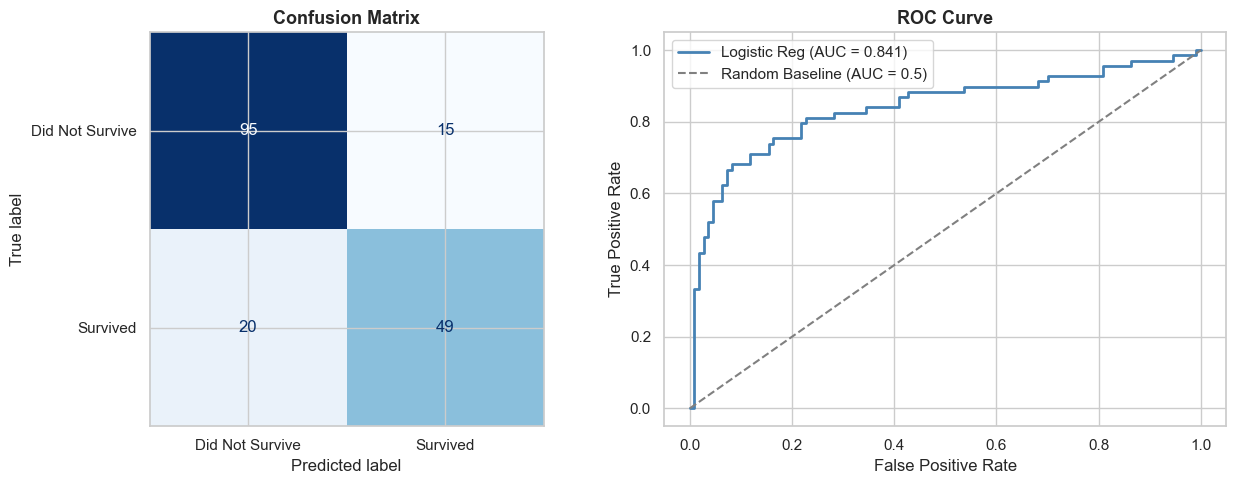

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Reg (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline (AUC = 0.5)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

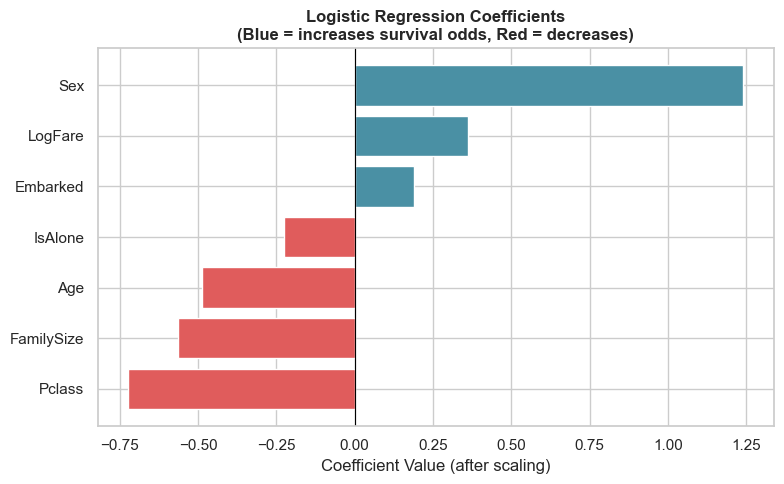

   Feature  Coefficient
    Pclass    -0.721796
FamilySize    -0.562586
       Age    -0.485877
   IsAlone    -0.224005
  Embarked     0.189855
   LogFare     0.360111
       Sex     1.239797


In [10]:
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient")

colors = ["#e05c5c" if c < 0 else "#4a90a4" for c in coef_df["Coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients\n(Blue = increases survival odds, Red = decreases)",
          fontsize=12, fontweight="bold")
plt.xlabel("Coefficient Value (after scaling)")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

In [12]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"\n  Mean:  {cv_scores.mean():.3f}")
print(f"  Std:   {cv_scores.std():.3f}")
print()
print("A low std (< 0.02) means the model is stable across different data splits.")

5-Fold Cross-Validation Accuracy:
  Fold 1: 0.760
  Fold 2: 0.787
  Fold 3: 0.781
  Fold 4: 0.798
  Fold 5: 0.826

  Mean:  0.790
  Std:   0.022

A low std (< 0.02) means the model is stable across different data splits.


In [14]:
import joblib
joblib.dump(pipe, "titanic_logistic_model.pkl")

['titanic_logistic_model.pkl']

# Part 2 — Linear Regression on House Prices

Go to this comp and join the comp:
kaggle.com/c/house-prices-advanced-regression-techniques

```bash
kaggle competitions download -c house-prices-advanced-regression-techniques
unzip house-prices-advanced-regression-techniques.zip
```

In [17]:
houses = pd.read_csv("train.csv")  # from the Kaggle competition zip
houses.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:

print("Shape:", houses.shape)
print("\nTarget — SalePrice:")
print(houses["SalePrice"].describe().apply(lambda x: f"${x:,.0f}"))

Shape: (1460, 81)

Target — SalePrice:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: str


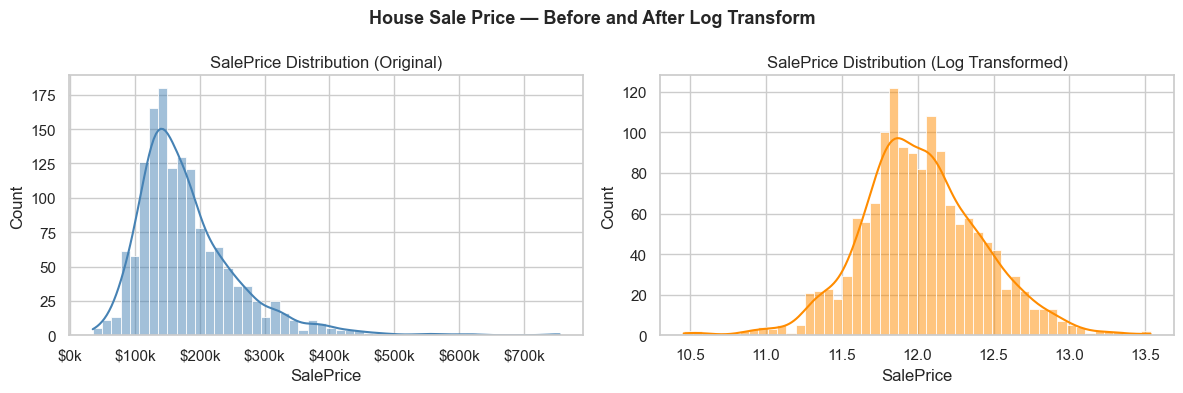

Original skew:          1.883
Log-transformed skew:   0.121

Linear regression assumes the target is roughly normally distributed.
High skew violates that assumption — log transform fixes it.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(houses["SalePrice"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice Distribution (Original)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.histplot(np.log1p(houses["SalePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("SalePrice Distribution (Log Transformed)")

plt.suptitle("House Sale Price — Before and After Log Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Original skew:          {houses['SalePrice'].skew():.3f}")
print(f"Log-transformed skew:   {np.log1p(houses['SalePrice']).skew():.3f}")
print()
print("Linear regression assumes the target is roughly normally distributed.")
print("High skew violates that assumption — log transform fixes it.")

In [ ]:
# Select intuitive numeric features for baseline
HOUSE_FEATURES = [
    "GrLivArea",      # Above-ground living area (sq ft)
    "OverallQual",    # Overall material and finish quality (1-10)
    "GarageCars",     # Garage capacity (number of cars)
    "TotalBsmtSF",    # Total basement area (sq ft)
    "FullBath",       # Full bathrooms above grade
    "YearBuilt",      # Original construction year
    "TotRmsAbvGrd",   # Total rooms above grade
]

houses_clean = houses[HOUSE_FEATURES + ["SalePrice"]].dropna()

# Log-transform the target
houses_clean["LogSalePrice"] = np.log1p(houses_clean["SalePrice"])

print(f"Rows after dropping any missing: {len(houses_clean)}")
houses_clean[HOUSE_FEATURES].describe().round(1)